# Gráficos que serão desenvolvidos 

- [Gráfico 1](#gr1): taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


- [Gráfico 2](#gr2): Taxa de utilização de Espaço da Rede: que é quão bem a abordagem está aproveitando o espaço de armazenamento disponível após uma falha na rede. Uma taxa alta indica uma boa utilização dos recursos 

- [Gráfico 3](#gr3): -Taxa de perda de benefícios: O quão o usuário foi prejudicado nessa realocação em comparação com a alocação antiga dele


- [Gráfico 4](#gr4): - tempo de realocação

### Configuração inicial

Importando bibliotecas necessárias

In [27]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd 
import seaborn as sns
#import plotly.graph_objects as go
import numpy as np
#import plotly.io as pio
#import plotly.express as px


import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

### Carregamento dos dados

In [28]:
results_flows_directories = glob.glob('../../results/results_flows*/*') # Caso mude a estrutura dos diretórios, esse caminho deve ser alterado
results_flows_directories

['../../results\\results_flows\\goku_backup_s_50_p_5_sfc_on_rel_1',
 '../../results\\results_flows\\goku_s_50_p_5_sfc_on_rel_1',
 '../../results\\results_flows\\msf_s_50_p_5_sfc_on_rel_1',
 '../../results\\results_flows\\musfico_s_50_p_5_sfc_on_rel_1']

Teste o 'for' abaixo e verifique se o alg_name aparece corretamente. Caso não apareça, provavelmente é porque sua máquina está lendo arquivos de forma diferente. Altere a linha do alg_name na função 'collect_data_from_alg_directory()' até que apareça corretamente. Você pode testar o loop abaixo, que é o mesmo que está inicialmente na função função 'collect_data_from_alg_directory()'

In [29]:
for alg_dir in results_flows_directories:
    simulacoes_okays = 0
    simu_exec_name = alg_dir.split('/')[-1].split('_')
    
    if simu_exec_name [2] == 'backup':
        alg_name = 'goku_backup'
    else:
        alg_name = simu_exec_name[1].split(f'\\')[1]
    reliability = simu_exec_name[-1]

In [30]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        
        if simu_exec_name [2] == 'backup':
            alg_name = 'goku_backup'
        else:
            alg_name = simu_exec_name[1].split(f'\\')[1]

        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'goku_backup':
            alg_name = 'Backup OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'

        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:

            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue
            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            
            if simulation_is_success: 
                # Seleciona as métricas
                simulation_df = simulation_df[metricas_coleta]
    
                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df['algorithm'] = alg_name
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]['simulacoes_sucesso'] += 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()
        
    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [31]:
metricas_coleta = [
    "time_seconds",
    "cpu_utilization",
    "bandwidth_utilization",
    "latency",
    "decision_time_ms",
    "success",
    "sfc_id",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "users_crashed","latency_diff","wait_time",'cpu_saved','shared_vnfs'
]

concatenate_simulation_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)


Resumo das Simulações:
Algoritmo: Backup OSCIM
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 99967

Algoritmo: OSCIM
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 60455

Algoritmo: MSF
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 66523

Algoritmo: MuSFiCO
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 66567



In [32]:
concatenate_simulation_data

,time_seconds,cpu_utilization,bandwidth_utilization,latency,decision_time_ms,success,sfc_id,crash_moment,recovery_time,sfc_recovered,running_sfcs,running_players,running_sessions,users_crashed,latency_diff,wait_time,cpu_saved,shared_vnfs,algorithm,simulation
0,0.0,0.0064,0.0000,0.0,3.256,1,sfc_cache_p1_1,0,NaN,NaN,1,1,1,0,NaN,NaN,0.000000,0,Backup OSCIM,0
1,0.0,0.0192,0.0000,0.0,3.134,1,sfc_unique_p1_1,0,NaN,NaN,2,1,1,0,NaN,NaN,0.000000,1,Backup OSCIM,0
2,0.0,0.0203,0.0000,0.0,1.974,1,sfc_cache_p2_1,0,NaN,NaN,3,2,1,0,NaN,NaN,6.333333,4,Backup OSCIM,0
3,0.1,0.0331,0.0000,0.0,1.901,1,sfc_unique_p2_1,0,NaN,NaN,4,2,1,0,NaN,NaN,6.333333,5,Backup OSCIM,0
4,0.1,0.0342,0.0000,0.0,1.914,1,sfc_cache_p3_1,0,NaN,NaN,5,3,1,0,NaN,NaN,12.666667,8,Backup OSCIM,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,1007.6,0.2770,0.1192,1.0,52.935,1,sfc_unique_p2_50,0,NaN,NaN,33,18,5,12,NaN,NaN,63.333333,42,MuSFiCO,29
514,1007.7,0.2782,0.1202,4.0,55.351,1,sfc_cache_p3_50,0,NaN,NaN,34,19,5,12,NaN,NaN,69.666667,45,MuSFiCO,29
515,1007.8,0.2921,0.1223,1.0,52.958,1,sfc_unique_p3_50,0,NaN,NaN,35,19,5,12,NaN,NaN,69.666667,46,MuSFiCO,29
516,1007.9,0.2933,0.1234,4.0,55.569,1,sfc_cache_p4_50,0,NaN,NaN,36,20,5,12,NaN,NaN,76.000000,49,MuSFiCO,29


In [41]:
data = concatenate_simulation_data.groupby(['algorithm', 'simulation'])

Função De Plot

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

def plot_metric_by_algorithm(data, metric, title, output_boxplot='boxplot.pdf', output_barplot='barplot.pdf', output_combined='combined_plot.pdf', save_individual=True):
    """
    Gera subplots com boxplot e barplot de uma métrica específica agrupada por algoritmo.
    
    Parâmetros:
    - data: DataFrame contendo os dados
    - metric: string, nome da métrica a ser plotada
    - title: string, título para os gráficos
    - output_boxplot: string, nome do arquivo para salvar o boxplot (default: 'boxplot.pdf')
    - output_barplot: string, nome do arquivo para salvar o barplot (default: 'barplot.pdf')
    - output_combined: string, nome do arquivo para salvar o plot combinado (default: 'combined_plot.pdf')
    - save_individual: boolean, se True, salva os plots individualmente e exibe o subplot; se False, salva e exibe apenas o subplot combinado.
    """
    # Cria a pasta de saída se não existir
    output_folder = "results"
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    output_combined = f'{metric}_plot.pdf'

    # Define os caminhos completos para salvar os arquivos
    boxplot_path = os.path.join(output_folder, output_boxplot)
    barplot_path = os.path.join(output_folder, output_barplot)
    combined_path = os.path.join(output_folder, output_combined)
    
    # Ordem dos algoritmos e cores correspondentes
    algorithms_order = ['Backup OSCIM', 'OSCIM', 'MSF', 'MuSFiCO']
    colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum']
    
    # Criação dos subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot do Boxplot no primeiro subplot
    sns.boxplot(x='algorithm', y=metric, data=data, 
                palette=dict(zip(algorithms_order, colors)), 
                order=algorithms_order, ax=axes[0])
    axes[0].set_title(f'{title} - Boxplot')
    axes[0].set_xlabel('Algorithm')
    axes[0].set_ylabel(title)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Cálculo da média e do desvio padrão para o barplot
    mean_rates = data.groupby('algorithm')[metric].mean()
    std_rates = data.groupby('algorithm')[metric].std()
    
    # Plot do Barplot no segundo subplot
    axes[1].bar(algorithms_order, mean_rates[algorithms_order], yerr=std_rates[algorithms_order], 
                capsize=5, color=colors, edgecolor='black')
    axes[1].set_title(f'{title} - Barplot')
    axes[1].set_xlabel('Algorithm')
    axes[1].set_ylabel(title)
    axes[1].set_ylim(0, max(mean_rates + std_rates) * 1.1)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Ajustar layout
    plt.tight_layout()

    # Salvar os gráficos conforme a escolha do usuário
    if save_individual:
        # Salvar os gráficos individuais "nos bastidores"
        fig_individual, ax = plt.subplots(figsize=(8, 6))
        sns.boxplot(x='algorithm', y=metric, data=data, 
                    palette=dict(zip(algorithms_order, colors)), 
                    order=algorithms_order, ax=ax)
        ax.set_title(f'{title} - Boxplot')
        ax.set_xlabel('Algorithm')
        ax.set_ylabel(title)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        fig_individual.savefig(boxplot_path)
        plt.close(fig_individual)  # Fechar o plot individual após salvar

        fig_individual, ax = plt.subplots(figsize=(8, 6))
        ax.bar(algorithms_order, mean_rates[algorithms_order], yerr=std_rates[algorithms_order], 
               capsize=5, color=colors, edgecolor='black')
        ax.set_title(f'{title} - Barplot')
        ax.set_xlabel('Algorithm')
        ax.set_ylabel(title)
        ax.set_ylim(0, max(mean_rates + std_rates) * 1.1)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        fig_individual.savefig(barplot_path)
        plt.close(fig_individual)  # Fechar o plot individual após salvar

        # Mostrar apenas o subplot combinado
        fig.savefig(combined_path)
        plt.show()
    else:
        # Salvar e mostrar o subplot combinado
        fig.savefig(combined_path)
        plt.show()

# Exemplo de uso:
# plot_metric_by_algorithm(df, 'cpu_utilization', 'CPU Utilization (%)', 'cpu_utilization_boxplot.pdf', 'cpu_utilization_barplot.pdf', 'cpu_utilization_combined.pdf', save_individual=True)


# Gráfico 1 <a id="gr1"></a>

taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


In [53]:
import pandas as pd

# Exemplo de função de cálculo de média
def calculate_mean(group):
    return group.mean()

# Supondo que 'data' é o seu DataFrame e 'sfc_recovered' é a coluna que você deseja aplicar
recovered_rate_mean_values = data['sfc_recovered'].apply(calculate_mean).reset_index()

# Renomeando a coluna resultante
recovered_rate_mean_values = recovered_rate_mean_values.rename(columns={0: 'sfc_recovered'})

# Agora, você tem um DataFrame com 'algorithm', 'simulation' e 'sfc_recovered'
df_recovered_sfcs = recovered_rate_mean_values[['algorithm', 'simulation', 'sfc_recovered']]

print(df_recovered_sfcs)


        algorithm  simulation  sfc_recovered
0    Backup OSCIM           0            1.0
1    Backup OSCIM           1            1.0
2    Backup OSCIM           2            1.0
3    Backup OSCIM           3            1.0
4    Backup OSCIM           4            1.0
..            ...         ...            ...
115         OSCIM          25            1.0
116         OSCIM          26            1.0
117         OSCIM          27            1.0
118         OSCIM          28            1.0
119         OSCIM          29            1.0

[120 rows x 3 columns]


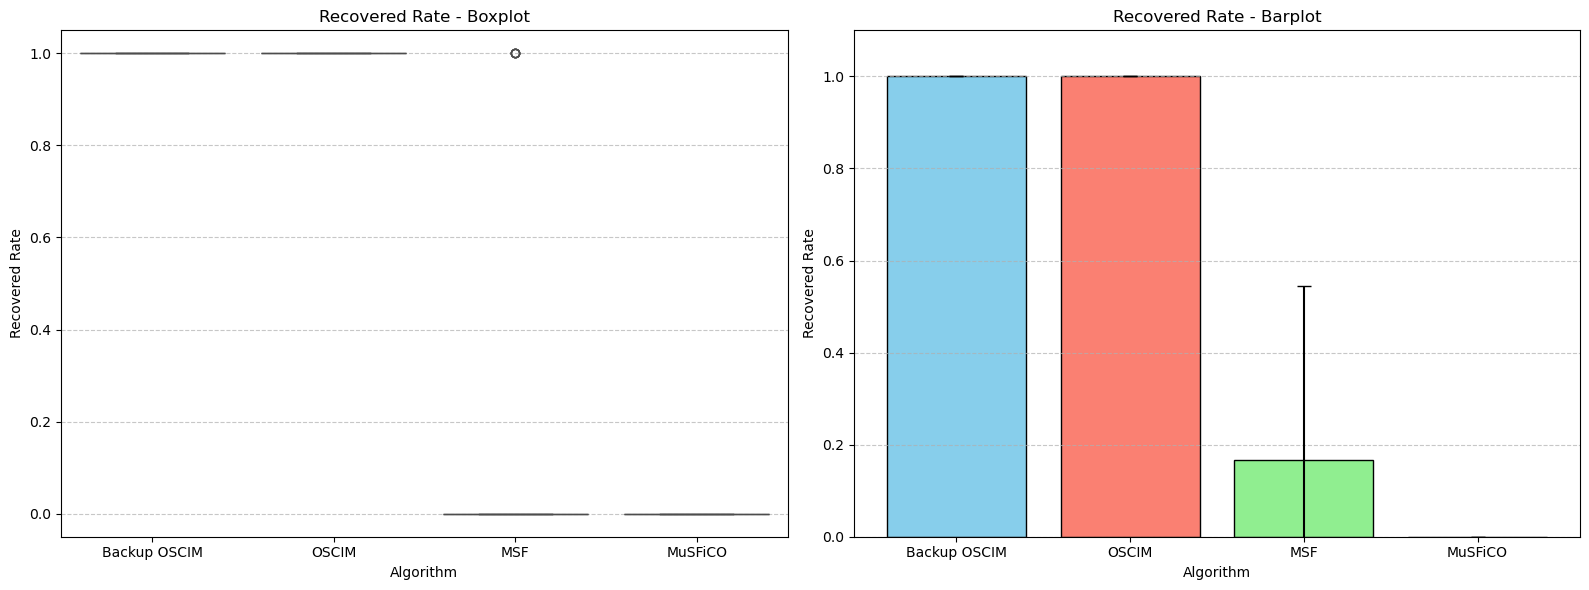

In [51]:
plot_metric_by_algorithm(df_recovered_sfcs, 'sfc_recovered', 'Recovered Rate', 'recovered_rate_boxplot.pdf', 'recovered_rate_barplot.pdf')

# Gráfico 2 Recovery Time <a id="gr2"></a>

Recovery time é muito parecido, porém a diferença é que nós não queremos coletar casos onde a sfc não conseguiu ser recuperada

In [55]:
import pandas as pd

# Exemplo de função de cálculo de média
def calculate_mean(group):
    return group.mean()

# Supondo que 'data' é o DataFrame já agrupado por 'algorithm' e 'simulation'
# Aplicando a função de média ao grupo
recovered_time_mean_values = data['recovery_time'].apply(calculate_mean).reset_index()

# Agora, você tem um DataFrame com 'algorithm', 'simulation' e 'recovery_time'
df_time_sfcs = recovered_time_mean_values[['algorithm', 'simulation', 'recovery_time']]

print(df_time_sfcs)


        algorithm  simulation  recovery_time
0    Backup OSCIM           0       0.431766
1    Backup OSCIM           1       1.104389
2    Backup OSCIM           2       0.988702
3    Backup OSCIM           3       0.180871
4    Backup OSCIM           4       0.890248
..            ...         ...            ...
115         OSCIM          25       0.146148
116         OSCIM          26       0.166338
117         OSCIM          27       0.594122
118         OSCIM          28       0.394718
119         OSCIM          29       0.411275

[120 rows x 3 columns]


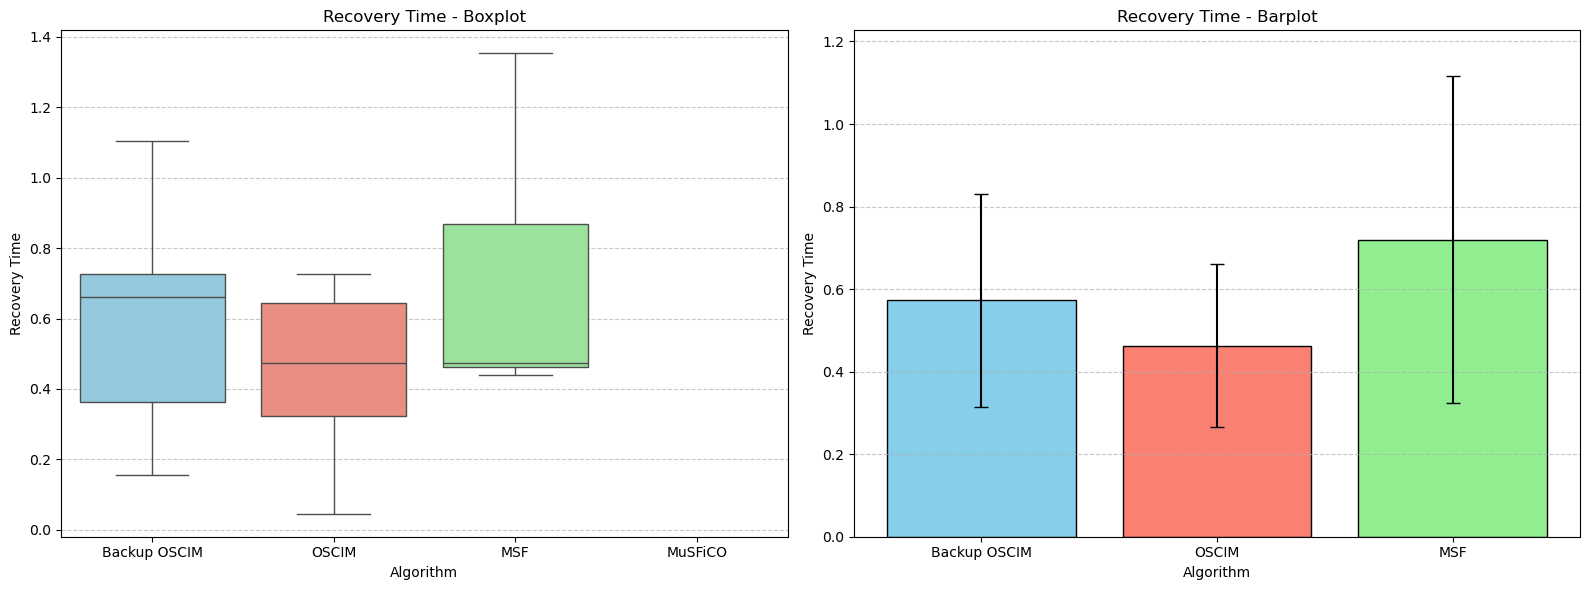

In [56]:
plot_metric_by_algorithm(df_time_sfcs, 'recovery_time', 'Recovery Time', 'recovery_time_boxplot.pdf', 'recovery_time_barplot.pdf')

# Gráfico 3 - latency diff

In [13]:
latency_diff_mean_values = data.apply(calculate_mean, 'latency_diff').reset_index(name='latency_diff')
df_latency_diff = latency_diff_mean_values[['algorithm', 'simulation', 'latency_diff']]

# Supondo que o DataFrame original seja chamado 'df'
# Definir os valores mínimo e máximo
min_value = -6
max_value = 6

# Criar uma nova coluna com a normalização
df_latency_diff['normalized_latency_diff'] = (df_latency_diff['latency_diff'] - min_value) / (max_value - min_value)

# Exibir o DataFrame resultante com a nova coluna
df_latency_diff

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

In [14]:
plot_metric_by_algorithm(df_latency_diff, 'normalized_latency_diff', 'Benefit Loss Rate', 'benefit_loss_rate_boxplot.pdf', 'benefit_loss_rate_barplot.pdf')

NameError: name 'df_latency_diff' is not defined

# Gráfico 4 Wait time <a id="gr3"></a>

In [15]:
wait_time_mean_values = data.apply(calculate_mean, 'wait_time').reset_index(name='wait_time')

df_wait_time_sfcs = wait_time_mean_values[['algorithm', 'simulation', 'wait_time']]

df_wait_time_sfcs

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

In [16]:
plot_metric_by_algorithm(df_wait_time_sfcs, 'wait_time', 'Time with High Latency', 'wait_time_boxplot.pdf', 'wait_time_barplot.pdf')

NameError: name 'df_wait_time_sfcs' is not defined

# Gráfico 5 - Acceptance <a id="gr5"></a>

In [17]:
import pandas as pd

# Supondo que o DataFrame original seja chamado 'concatenate_simulation_data' e contenha as colunas 'sfc_id' e 'algorithm'
# Criar uma função que verifica se a SFC é de backup
def is_backup(row):
    session_number = int(row['sfc_id'].split('_')[-1])  # Obtém o número da sessão
    algorithm_is_backup = row['algorithm'].startswith('Backup')  # Verifica se o algoritmo começa com 'Backup'
    return session_number % 2 == 0 and algorithm_is_backup  # True se a sessão for par e o algoritmo for de backup

# Aplicar a função para criar a nova coluna 'backup_sfc'
concatenate_simulation_data['backup_sfc'] = concatenate_simulation_data.apply(is_backup, axis=1)

# Filtrar para selecionar apenas as SFCs que não são de backup
non_backup_sfcs = concatenate_simulation_data[~concatenate_simulation_data['backup_sfc']]

# Exibir o DataFrame resultante sem as SFCs de backup
non_backup_sfcs = non_backup_sfcs.groupby(['algorithm','simulation'])

success_mean_values = non_backup_sfcs.apply(calculate_mean, 'success').reset_index(name='success')

df_success_sfcs = success_mean_values[['algorithm', 'simulation', 'success']]

df_success_sfcs

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

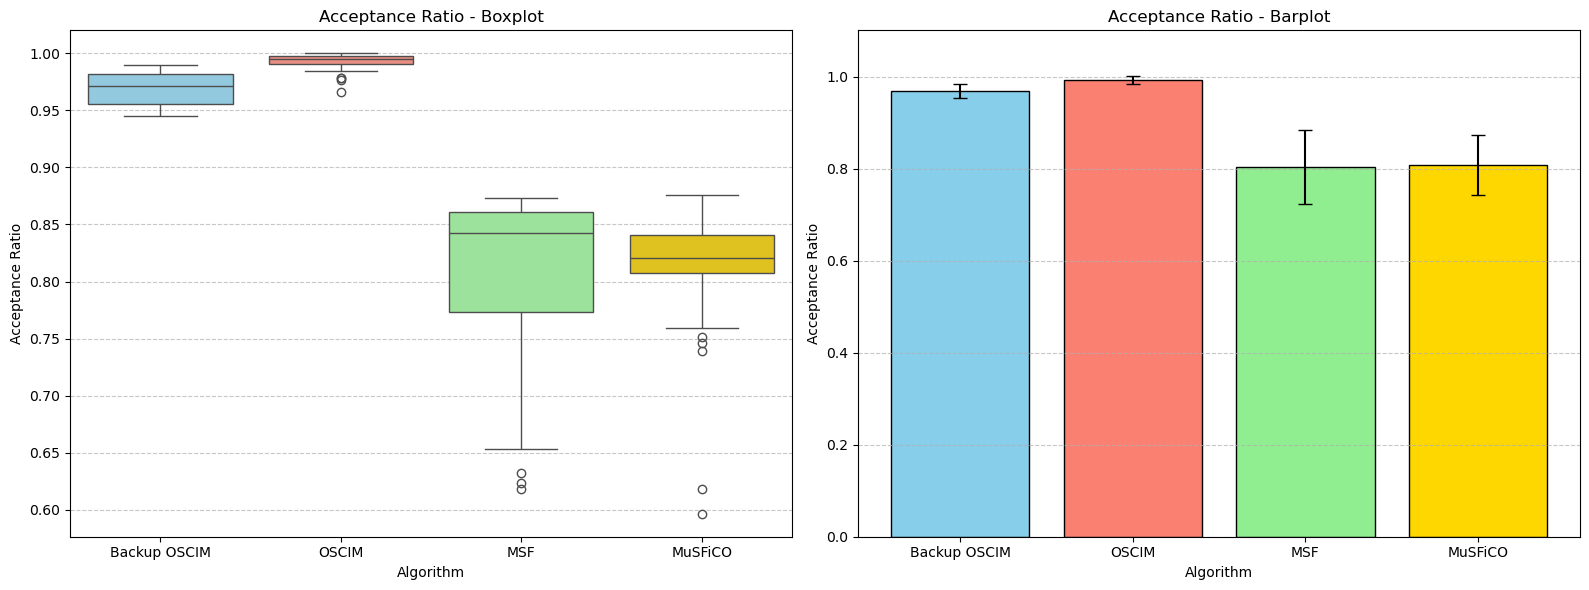

In [ ]:
plot_metric_by_algorithm(df_success_sfcs, 'success', 'Acceptance Ratio', 'sucess_boxplot.pdf', 'sucess_barplot.pdf')

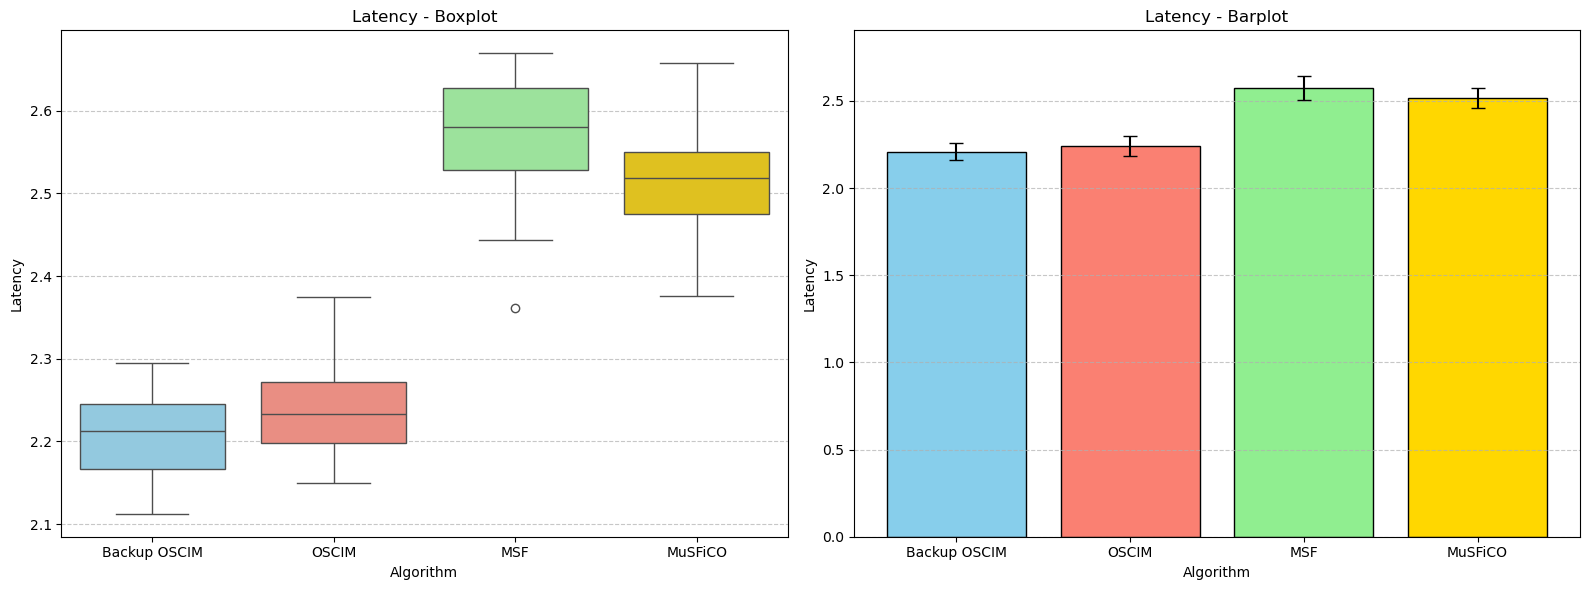

In [ ]:
# Aplicar a função de média em cada grupo
latency_mean_values = data.apply(calculate_mean, 'latency').reset_index(name='latency')

# Agora, você tem um DataFrame com 'algorithm', 'simulation' e 'recovered_sfcs'
df_latency_sfcs = latency_mean_values[['algorithm', 'simulation', 'latency']]

# Exibir o DataFrame resultante
df_latency_sfcs

plot_metric_by_algorithm(df_latency_sfcs, 'latency', 'Latency', 'latency_boxplot.pdf', 'latency_barplot.pdf')

# Métricas Clássicas

ACEITAÇÃO

CPU
CPU/PER FLOW

BANDA
BANDA/PER FLOW

REÚSO
REÚSO PER FLOW

Latência

Decision Time

In [18]:
concatenate_simulation_data

,time_seconds,cpu_utilization,bandwidth_utilization,latency,decision_time_ms,success,sfc_id,crash_moment,recovery_time,sfc_recovered,...,running_players,running_sessions,users_crashed,latency_diff,wait_time,cpu_saved,shared_vnfs,algorithm,simulation,backup_sfc
0,0.0,0.0064,0.0000,0.0,3.256,1,sfc_cache_p1_1,0,NaN,NaN,...,1,1,0,NaN,NaN,0.000000,0,Backup OSCIM,0,False
1,0.0,0.0192,0.0000,0.0,3.134,1,sfc_unique_p1_1,0,NaN,NaN,...,1,1,0,NaN,NaN,0.000000,1,Backup OSCIM,0,False
2,0.0,0.0203,0.0000,0.0,1.974,1,sfc_cache_p2_1,0,NaN,NaN,...,2,1,0,NaN,NaN,6.333333,4,Backup OSCIM,0,False
3,0.1,0.0331,0.0000,0.0,1.901,1,sfc_unique_p2_1,0,NaN,NaN,...,2,1,0,NaN,NaN,6.333333,5,Backup OSCIM,0,False
4,0.1,0.0342,0.0000,0.0,1.914,1,sfc_cache_p3_1,0,NaN,NaN,...,3,1,0,NaN,NaN,12.666667,8,Backup OSCIM,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,1007.6,0.2770,0.1192,1.0,52.935,1,sfc_unique_p2_50,0,NaN,NaN,...,18,5,12,NaN,NaN,63.333333,42,MuSFiCO,29,False
514,1007.7,0.2782,0.1202,4.0,55.351,1,sfc_cache_p3_50,0,NaN,NaN,...,19,5,12,NaN,NaN,69.666667,45,MuSFiCO,29,False
515,1007.8,0.2921,0.1223,1.0,52.958,1,sfc_unique_p3_50,0,NaN,NaN,...,19,5,12,NaN,NaN,69.666667,46,MuSFiCO,29,False
516,1007.9,0.2933,0.1234,4.0,55.569,1,sfc_cache_p4_50,0,NaN,NaN,...,20,5,12,NaN,NaN,76.000000,49,MuSFiCO,29,False


## Métricas que não precisam de ajuste
- CPU
- BANDA
- decision_time_ms

In [19]:
consume_metrics = concatenate_simulation_data[['cpu_utilization', 'bandwidth_utilization','cpu_saved','shared_vnfs','simulation','decision_time_ms','algorithm']]

In [20]:
df_consume_metrics = consume_metrics.groupby(['algorithm','simulation']).mean().reset_index()
df_consume_metrics

,algorithm,simulation,cpu_utilization,bandwidth_utilization,cpu_saved,shared_vnfs,decision_time_ms
0,Backup OSCIM,0,0.447048,0.103680,97.760303,83.039191,2.338408
1,Backup OSCIM,1,0.468712,0.109329,91.661430,81.041147,2.397404
2,Backup OSCIM,2,0.469204,0.110134,91.115273,81.699126,2.425966
3,Backup OSCIM,3,0.443681,0.104205,95.825232,80.969620,2.411889
4,Backup OSCIM,4,0.655892,0.145225,167.612859,123.036205,2.696102
...,...,...,...,...,...,...,...
115,OSCIM,25,0.431873,0.103617,101.333333,69.090551,2.277480
116,OSCIM,26,0.438346,0.105292,101.582677,69.606299,2.329850
117,OSCIM,27,0.450091,0.111671,105.916187,72.168906,2.389956
118,OSCIM,28,0.446517,0.111068,107.220483,72.737769,2.447748


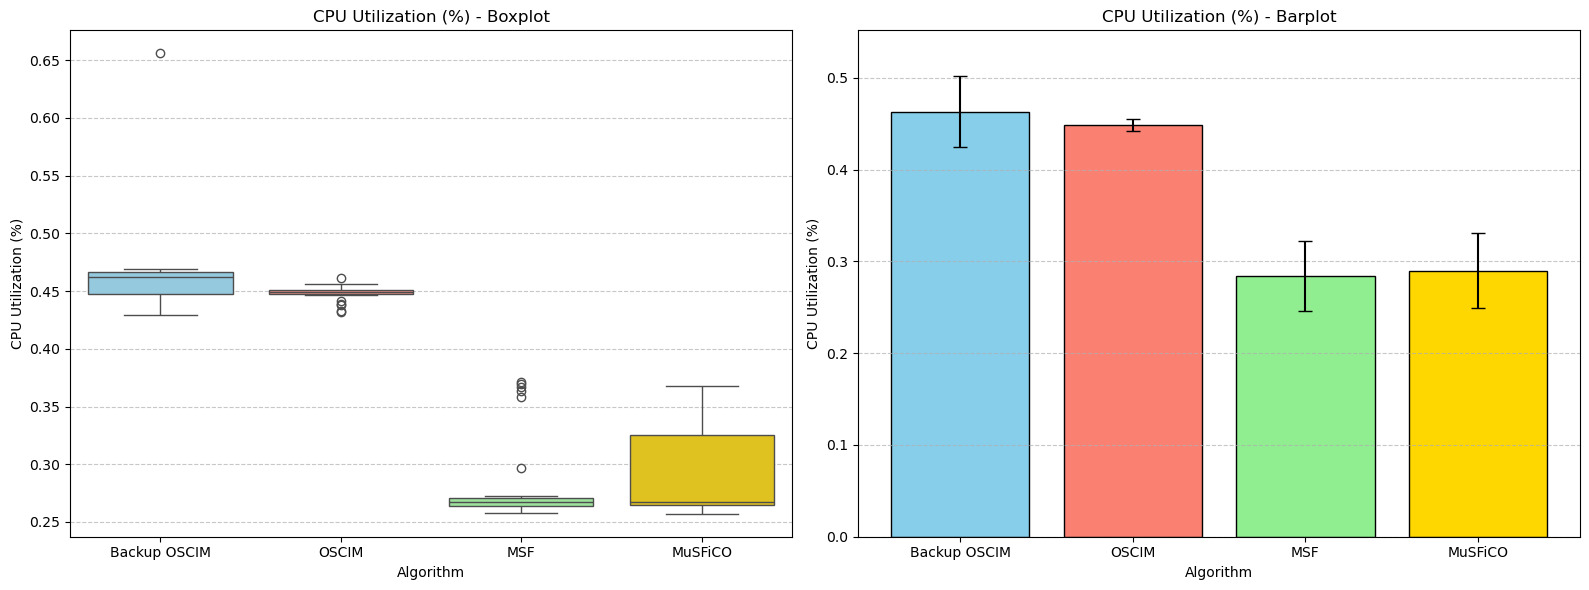

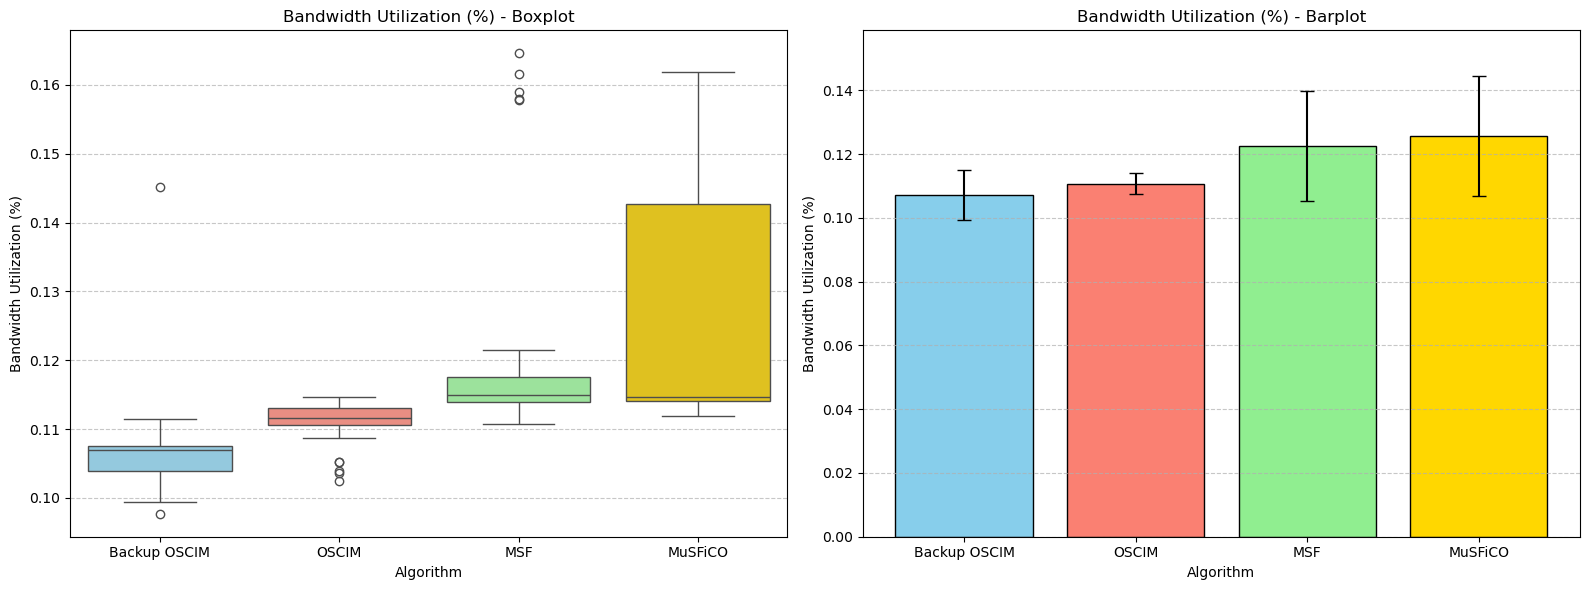

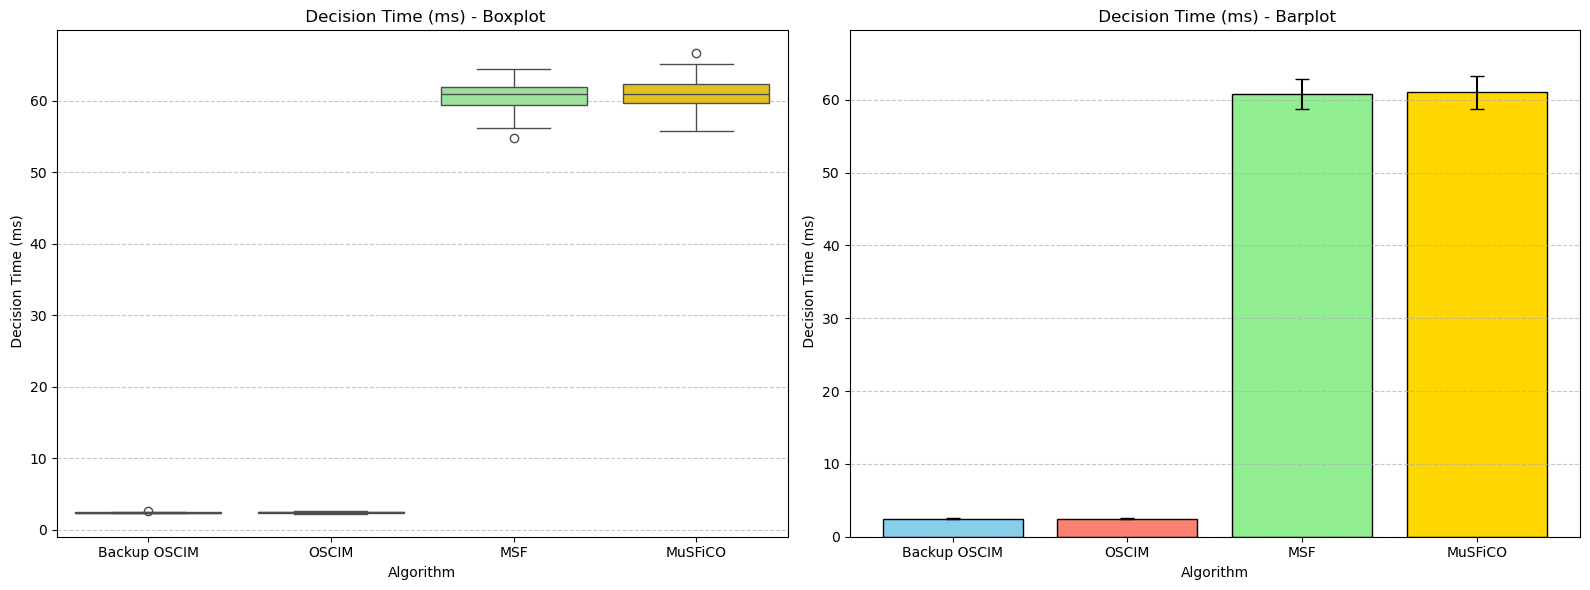

In [21]:
# Lista de métricas e seus títulos correspondentes
metrics = [
    ('cpu_utilization', 'CPU Utilization (%)'),
    ('bandwidth_utilization', 'Bandwidth Utilization (%)'),
    ('decision_time_ms',' Decision Time (ms)')
]

# Loop para gerar gráficos para cada métrica
for metric, title in metrics:
    boxplot_filename = f'{metric}_boxplot.pdf'
    barplot_filename = f'{metric}_barplot.pdf'
    
    plot_metric_by_algorithm(df_consume_metrics, metric, title, boxplot_filename, barplot_filename)

In [22]:
consume_metrics

,cpu_utilization,bandwidth_utilization,cpu_saved,shared_vnfs,simulation,decision_time_ms,algorithm
0,0.0064,0.0000,0.000000,0,0,3.256,Backup OSCIM
1,0.0192,0.0000,0.000000,1,0,3.134,Backup OSCIM
2,0.0203,0.0000,6.333333,4,0,1.974,Backup OSCIM
3,0.0331,0.0000,6.333333,5,0,1.901,Backup OSCIM
4,0.0342,0.0000,12.666667,8,0,1.914,Backup OSCIM
...,...,...,...,...,...,...,...
513,0.2770,0.1192,63.333333,42,29,52.935,MuSFiCO
514,0.2782,0.1202,69.666667,45,29,55.351,MuSFiCO
515,0.2921,0.1223,69.666667,46,29,52.958,MuSFiCO
516,0.2933,0.1234,76.000000,49,29,55.569,MuSFiCO


In [23]:
import pandas as pd

# Supondo que o DataFrame original seja chamado 'concatenate_simulation_data' e contenha as colunas 'sfc_id' e 'algorithm'
# Criar uma função que verifica se a SFC é de backup
def is_backup(row):
    session_number = int(row['sfc_id'].split('_')[-1])  # Obtém o número da sessão
    algorithm_is_backup = row['algorithm'].startswith('Backup')  # Verifica se o algoritmo começa com 'Backup'
    return session_number % 2 == 0 and algorithm_is_backup  # True se a sessão for par e o algoritmo for de backup

# Aplicar a função para criar a nova coluna 'backup_sfc'
concatenate_simulation_data['backup_sfc'] = concatenate_simulation_data.apply(is_backup, axis=1)

# Filtrar para selecionar apenas as SFCs que não são de backup
non_backup_sfcs = concatenate_simulation_data[~concatenate_simulation_data['backup_sfc']]
consume_metrics = non_backup_sfcs[['cpu_saved','shared_vnfs','simulation','algorithm']]

# # Exibir o DataFrame resultante sem as SFCs de backup
# non_backup_sfcs_shared = non_backup_sfcs.groupby(['algorithm','simulation','cpu_saved','shared_vnfs'])

# shared = non_backup_sfcs.apply(calculate_mean, 'success').reset_index(name='success')

# df_success_sfcs = success_mean_values[['algorithm', 'simulation', 'success']]

# df_success_sfcs

In [24]:
df_consume_metrics = consume_metrics.groupby(['algorithm','simulation']).mean().reset_index()

In [25]:
df_consume_metrics

,algorithm,simulation,cpu_saved,shared_vnfs
0,Backup OSCIM,0,99.093542,83.677104
1,Backup OSCIM,1,92.365134,80.791188
2,Backup OSCIM,2,91.897121,81.358925
3,Backup OSCIM,3,96.418431,81.125490
4,Backup OSCIM,4,165.527127,121.038388
...,...,...,...,...
115,OSCIM,25,101.333333,69.090551
116,OSCIM,26,101.582677,69.606299
117,OSCIM,27,105.916187,72.168906
118,OSCIM,28,107.220483,72.737769


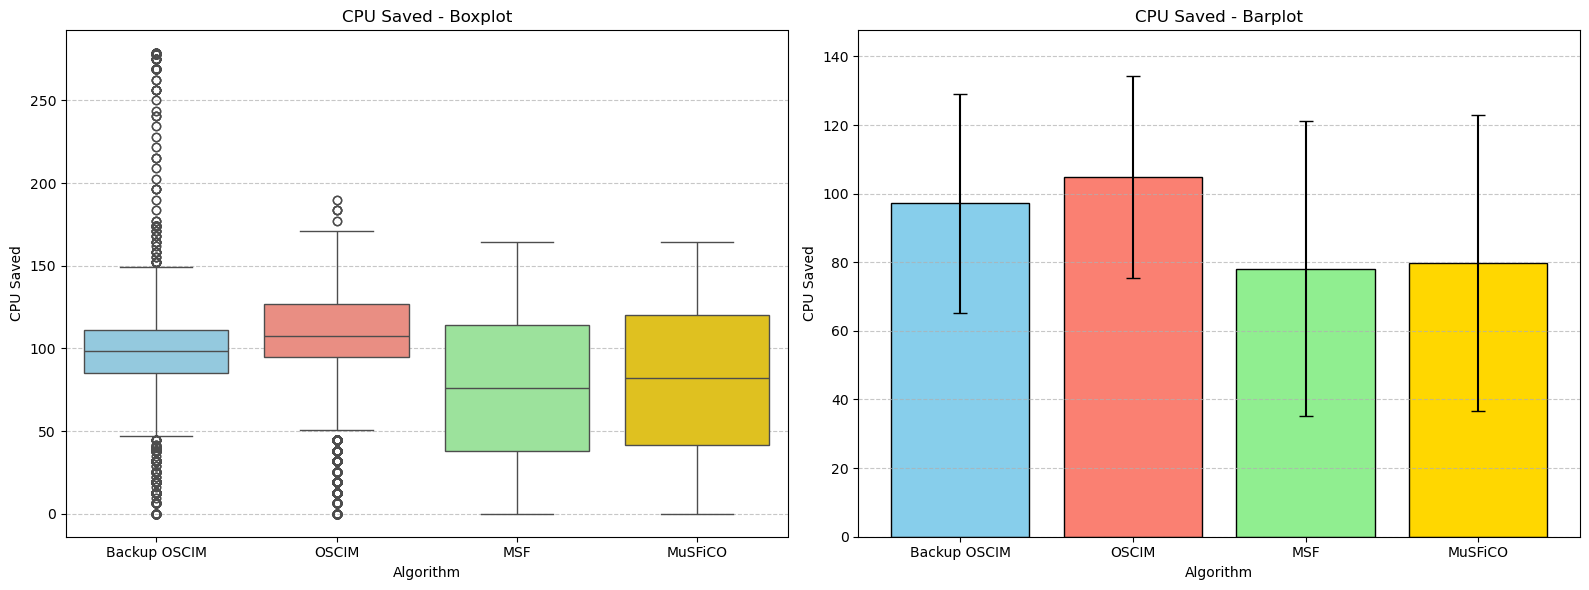

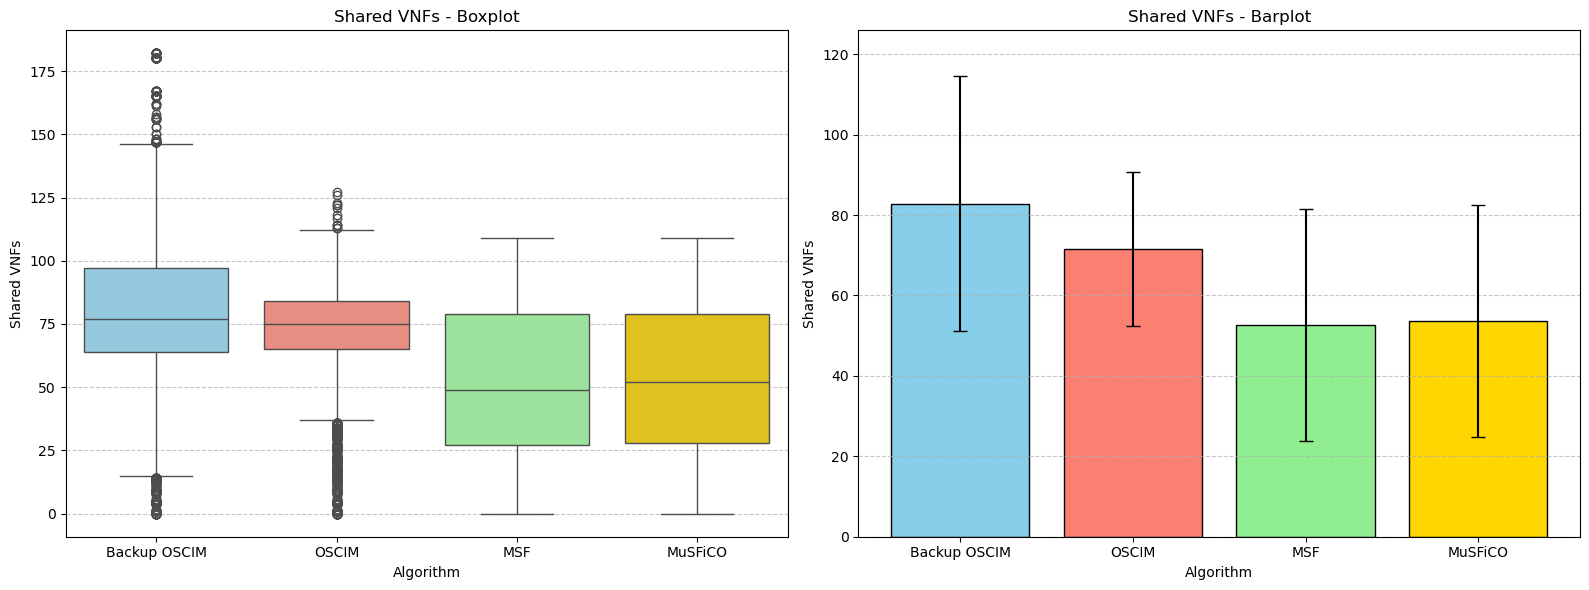

In [26]:
# Lista de métricas e seus títulos correspondentes
metrics = [
    ('cpu_saved', 'CPU Saved'),
    ('shared_vnfs', 'Shared VNFs')
]

# Loop para gerar gráficos para cada métrica
for metric, title in metrics:
    boxplot_filename = f'{metric}_boxplot.pdf'
    barplot_filename = f'{metric}_barplot.pdf'
    
    plot_metric_by_algorithm(non_backup_sfcs, metric, title, boxplot_filename, barplot_filename)